# Segmentação Semântica com Oxford-IIIT Pet para App Android

Este notebook foi criado para uso no Google Colab com GPU. Ele treina um modelo de segmentação semântica no dataset Oxford-IIIT Pet, avalia IoU e acurácia, e exporta o modelo para uso em um aplicativo Android (Flutter + Dart + Java).

**Passos:**
1. Configurar runtime do Colab para GPU.
2. Fazer download do dataset Oxford-IIIT Pet.
3. Treinar modelo UNet leve.
4. Avaliar métricas e visualizar predições.
5. Exportar modelo TorchScript / ONNX para Android.

In [9]:
# Instala dependências no Colab, se necessário
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip install -q torch torchvision torchmetrics
    !pip install -q tensorflow==2.20.0 onnx onnxruntime onnxscript onnx2tf

import random
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import OxfordIIITPet
from torchmetrics import JaccardIndex

print('Torch version:', torch.__version__)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 779.7 kB/s eta 0:00:00
Torch version: 2.11.0+cu128
Device: cuda


## 1. Dataset e Pré-processamento

Usamos o dataset `OxfordIIITPet` com a variável `target_types='segmentation'`. O notebook reduz o tamanho das imagens para 128×128 para acelerar o treinamento no Colab e manter o modelo leve para uso móvel.

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

IMAGE_SIZE = 128
BATCH_SIZE = 16
NUM_CLASSES = 3  # background, pet, contour

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

image_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

mask_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE), interpolation=transforms.InterpolationMode.NEAREST),
    transforms.PILToTensor(),
    transforms.Lambda(lambda x: x.squeeze(0).long()),
    transforms.Lambda(lambda x: x - 1),  # classes 1,2,3 -> 0,1,2
])

class PetSegmentationDataset(OxfordIIITPet):
    def __init__(self, root, split, transform=None, target_transform=None, download=False):
        super().__init__(root=root, split=split, target_types='segmentation', transform=transform, target_transform=target_transform, download=download)

    def __getitem__(self, index):
        image, mask = super().__getitem__(index)
        return image, mask

dataset_trainval = PetSegmentationDataset(
    root='data',
    split='trainval',
    transform=image_transform,
    target_transform=mask_transform,
    download=True,
)
dataset_test = PetSegmentationDataset(
    root='data',
    split='test',
    transform=image_transform,
    target_transform=mask_transform,
    download=True,
)

n_trainval = len(dataset_trainval)
n_train = int(0.8 * n_trainval)
n_val = n_trainval - n_train
train_dataset, val_dataset = torch.utils.data.random_split(
    dataset_trainval, [n_train, n_val], generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=device.type == 'cuda')
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=device.type == 'cuda')
test_loader = DataLoader(dataset_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=device.type == 'cuda')

print('Tamanho treino:', len(train_dataset))
print('Tamanho validação:', len(val_dataset))
print('Tamanho teste:', len(dataset_test))

Tamanho treino: 2944
Tamanho validação: 736
Tamanho teste: 3669


## 2. Modelo UNet leve

A arquitetura UNet é eficiente para segmentação e produz mapas de máscara no mesmo tamanho da entrada. Aqui usamos um modelo leve para rodar com GPU em Colab e ser exportável para mobile.

In [3]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

class UNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.down1 = DoubleConv(3, 32)
        self.pool1 = nn.MaxPool2d(2)
        self.down2 = DoubleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)
        self.down3 = DoubleConv(64, 128)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(128, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv3 = DoubleConv(256, 128)
        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv2 = DoubleConv(128, 64)
        self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.conv1 = DoubleConv(64, 32)

        self.final = nn.Conv2d(32, num_classes, kernel_size=1)

    def forward(self, x):
        x1 = self.down1(x)
        x2 = self.pool1(x1)
        x3 = self.down2(x2)
        x4 = self.pool2(x3)
        x5 = self.down3(x4)
        x6 = self.pool3(x5)

        x7 = self.bottleneck(x6)
        x8 = self.up3(x7)
        x8 = torch.cat([x5, x8], dim=1)
        x8 = self.conv3(x8)
        x9 = self.up2(x8)
        x9 = torch.cat([x3, x9], dim=1)
        x9 = self.conv2(x9)
        x10 = self.up1(x9)
        x10 = torch.cat([x1, x10], dim=1)
        x10 = self.conv1(x10)
        return self.final(x10)

model = UNet(num_classes=NUM_CLASSES).to(device)
print(model)

UNet(
  (down1): DoubleConv(
    (block): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (down2): DoubleConv(
    (block): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
 

## 3. Funções de treino e avaliação

Esta célula define o loop de treinamento, a métrica de IoU e a acurácia de pixels.

In [4]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
iou_metric = JaccardIndex(task='multiclass', num_classes=NUM_CLASSES).to(device)

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_pixels = 0
    for imgs, masks in loader:
        imgs = imgs.to(device)
        masks = masks.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        preds = logits.argmax(dim=1)
        total_correct += (preds == masks).sum().item()
        total_pixels += masks.numel()
    return total_loss / len(loader.dataset), total_correct / total_pixels

@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_pixels = 0
    iou_metric.reset()
    for imgs, masks in loader:
        imgs = imgs.to(device)
        masks = masks.to(device)
        logits = model(imgs)
        loss = criterion(logits, masks)
        total_loss += loss.item() * imgs.size(0)
        preds = logits.argmax(dim=1)
        total_correct += (preds == masks).sum().item()
        total_pixels += masks.numel()
        iou_metric.update(preds, masks)
    return total_loss / len(loader.dataset), total_correct / total_pixels, iou_metric.compute().cpu().numpy()

def plot_history(history):
    epochs = list(range(1, len(history['train_loss']) + 1))
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, history['train_loss'], label='train loss')
    plt.plot(epochs, history['val_loss'], label='val loss')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(epochs, history['train_acc'], label='train acc')
    plt.plot(epochs, history['val_acc'], label='val acc')
    plt.xlabel('Epoch'); plt.ylabel('Pixel Acc'); plt.legend()
    plt.show()

## 4. Treinamento

Execute o treinamento por algumas épocas. Em Colab com GPU, 10-12 épocas já fornecem uma boa base de segmentação para este modelo leve.

Epoch 1/10 | train_loss=0.6614 train_acc=0.7265 | val_loss=0.6012 val_acc=0.7530 val_iou=0.49630045890808105
Epoch 2/10 | train_loss=0.5295 train_acc=0.7899 | val_loss=0.4906 val_acc=0.8088 val_iou=0.5549508333206177
Epoch 3/10 | train_loss=0.4602 train_acc=0.8189 | val_loss=0.5854 val_acc=0.7799 val_iou=0.552641749382019
Epoch 4/10 | train_loss=0.4147 train_acc=0.8378 | val_loss=0.4284 val_acc=0.8332 val_iou=0.6074529886245728
Epoch 5/10 | train_loss=0.3963 train_acc=0.8460 | val_loss=0.4216 val_acc=0.8367 val_iou=0.6233417987823486
Epoch 6/10 | train_loss=0.3778 train_acc=0.8531 | val_loss=0.3616 val_acc=0.8616 val_iou=0.6562729477882385
Epoch 7/10 | train_loss=0.3559 train_acc=0.8622 | val_loss=0.3552 val_acc=0.8636 val_iou=0.6599941253662109
Epoch 8/10 | train_loss=0.3451 train_acc=0.8668 | val_loss=0.3479 val_acc=0.8667 val_iou=0.6656650304794312
Epoch 9/10 | train_loss=0.3332 train_acc=0.8713 | val_loss=0.4031 val_acc=0.8451 val_iou=0.6414768695831299
Epoch 10/10 | train_loss=0.3

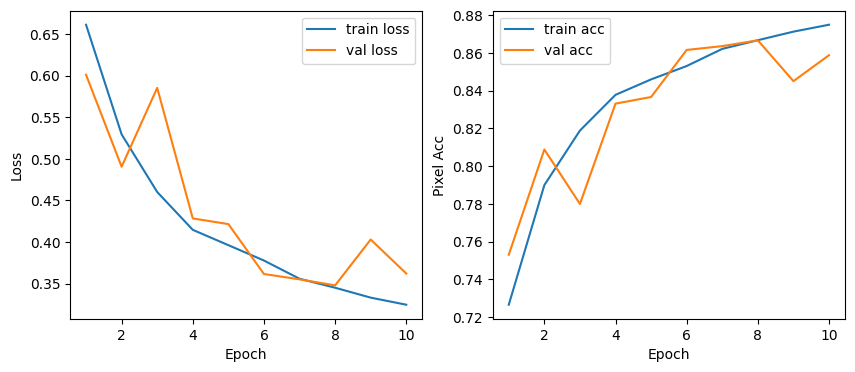

Melhor modelo carregado com val_loss = 0.3479282094732575


In [5]:
NUM_EPOCHS = 10
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss = float('inf')
best_model = None

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc, val_iou = eval_epoch(model, val_loader, criterion)
    scheduler.step(val_loss)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f'Epoch {epoch}/{NUM_EPOCHS} | train_loss={train_loss:.4f} train_acc={train_acc:.4f} | val_loss={val_loss:.4f} val_acc={val_acc:.4f} val_iou={val_iou}')
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = model.state_dict()

plot_history(history)
model.load_state_dict(best_model)
print('Melhor modelo carregado com val_loss =', best_val_loss)

## 5. Avaliação final no conjunto de teste

Calcula a IoU média e a acurácia de pixels no conjunto de teste final.

In [6]:
test_loss, test_acc, test_iou = eval_epoch(model, test_loader, criterion)
print(f'Teste loss={test_loss:.4f} | test_acc={test_acc:.4f} | test_iou={test_iou}')

Teste loss=0.3764 | test_acc=0.8546 | test_iou=0.6553055644035339


## 6. Visualização das predições

Mostra algumas imagens de teste, as máscaras verdadeiras e as predições geradas pelo modelo.

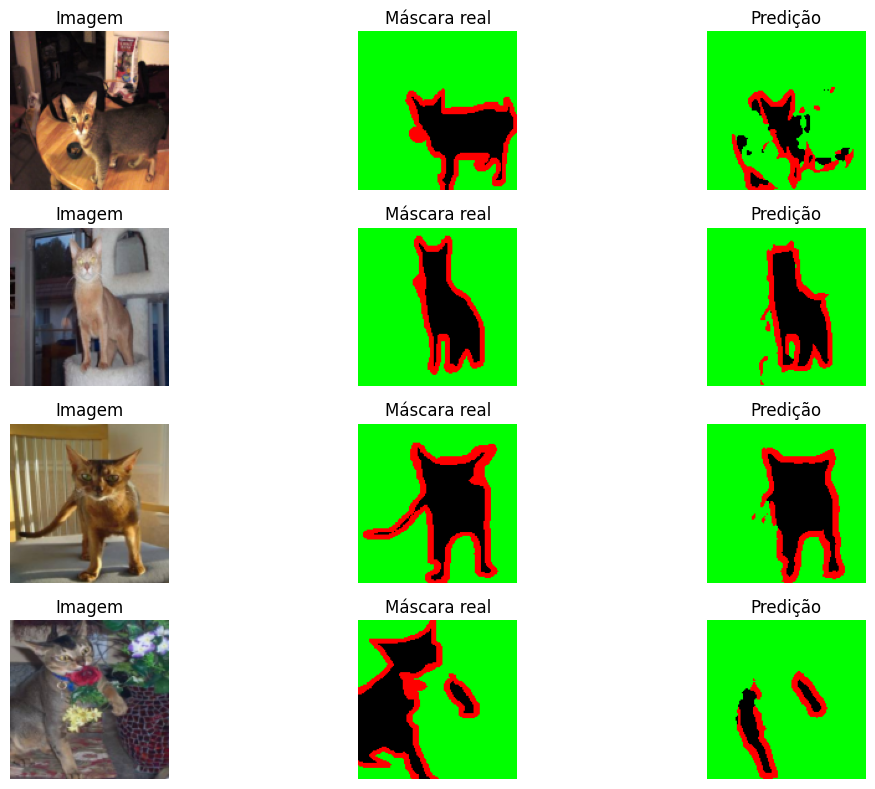

In [7]:
def decode_mask(mask):
    colors = np.array([[0, 0, 0], [0, 255, 0], [255, 0, 0]], dtype=np.uint8)
    mask = mask.astype(np.uint8)
    return colors[mask]

def denormalize(image_tensor):
    image = image_tensor.cpu().numpy().transpose(1, 2, 0)
    image = image * np.array(std) + np.array(mean)
    return np.clip(image, 0, 1)

model.eval()
with torch.no_grad():
    batch = next(iter(test_loader))
    imgs, masks = batch
    imgs = imgs.to(device)
    logits = model(imgs)
    preds = logits.argmax(dim=1).cpu().numpy()
    masks = masks.numpy()
    imgs = imgs.cpu()

    n_show = min(4, imgs.size(0))
    plt.figure(figsize=(12, 8))
    for i in range(n_show):
        plt.subplot(n_show, 3, 3*i + 1)
        plt.imshow(denormalize(imgs[i]))
        plt.title('Imagem')
        plt.axis('off')
        plt.subplot(n_show, 3, 3*i + 2)
        plt.imshow(decode_mask(masks[i]))
        plt.title('Máscara real')
        plt.axis('off')
        plt.subplot(n_show, 3, 3*i + 3)
        plt.imshow(decode_mask(preds[i]))
        plt.title('Predição')
        plt.axis('off')
    plt.tight_layout()

## 7. Exportação para aplicativo Android

Este notebook salva o modelo para uso em Android/Flutter. O fluxo recomendado é exportar para TorchScript e, opcionalmente, para ONNX. O arquivo pode ser copiado para `assets` do app Android.

In [12]:
import os
import subprocess
import torch
import shutil

# 1. Preparação
output_dir = 'exported_model'
os.makedirs(output_dir, exist_ok=True)
model_cpu = model.to('cpu').eval()
dummy_input = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE)

# 2. Exportação ONNX
onnx_path = os.path.join(output_dir, 'model.onnx')
torch.onnx.export(model_cpu, dummy_input, onnx_path, opset_version=18)

# 3. ONNX -> TFLite
print("Convertendo para TFLite...")
subprocess.run(['onnx2tf', '-i', onnx_path, '-o', output_dir], capture_output=True)

# 4. Localizar e Mover o arquivo TFLite para a raiz
tflite_filename = 'pet_segmentation_unet_float32.tflite'
found_path = None
for root, dirs, files_in_dir in os.walk(output_dir):
    for f in files_in_dir:
        if f == tflite_filename:
            found_path = os.path.join(root, f)
            shutil.move(found_path, tflite_filename)
            break

# 5. Download
if IN_COLAB:
    from google.colab import files
    if os.path.exists(tflite_filename):
        print(f'Baixando: {tflite_filename}')
        files.download(tflite_filename)
    else:
        print("Erro: O arquivo .tflite não foi encontrado. Verifique se a conversão onnx2tf falhou.")

TorchScript exportado: exported_model/pet_segmentation_unet.pt
[torch.onnx] Obtain model graph for `UNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `UNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
Applied 14 of general pattern rewrite rules.
[torch.onnx] Optimize the ONNX graph... ✅
ONNX exportado.
Convertendo para TFLite...

--- Downloads ---


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Encontrado TFLite em: exported_model/saved_model/pet_segmentation_unet_float32.tflite


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>